# Acquisition

A task configured, read in a loop, scaled into a frame, drawn live.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 What the board can record

`catalogue()` is the board's list. AFE_ON off reads mid-scale and 25.00 C (invariant 9): `enable()` takes the rail, `close()` gives it back.

In [3]:
daq = device.daq
daq.open()
for row in daq.catalogue():
    print('%-16s %-8s %-4s %-10s selectable=%s'
          % (row['name'], row['kind'], row['direction'], row['unit'],
             row['selectable']))
daq.enable()
print(device.afe.state())

Phase U          analog   in   mA         selectable=True
Phase V          analog   in   mA         selectable=True
Phase W          analog   in   mA         selectable=True
Clevel           analog   in   None       selectable=True
NTC              analog   in   centi-degC selectable=True
DC bus           analog   in   mV         selectable=True
Cinj             analog   in   None       selectable=True
+5V              analog   in   mV         selectable=True
Vgate            analog   in   mV         selectable=True
MCU die          analog   in   centi-degC selectable=True
AFE_ON           digital  out  duty       selectable=True
UART5_TERM       digital  out  duty       selectable=True
KEEPALIVE        digital  out  duty       selectable=True
orientation      sensor   in   quaternion selectable=True
acceleration     sensor   in   m/s^2      selectable=True
rotation rate    sensor   in   rad/s      selectable=True
magnetic field   sensor   in   uT         selectable=True
shaft angle   

## 3 The clock

The board counts cycles: `set_time_from_pc` ties them to the host clock, `reference='utc'` to NTP.

In [4]:
sync = device.set_time_from_pc(reference='pc')
print(sync)

<Sync 474.993937 MHz (-12.8 ppm vs pc, floor 0.2 ppm), reference +/- 1 us>


## 4 A task, read in a loop

`start()` puts a reader thread on the link; `read(-1)` is its backlog.

In [5]:
import time

layout = daq.configure('phaseU', 'NTC', sample_rate=50)
print(daq.channel_names())
print(layout)
daq.start()
records = []
for _ in range(5):
    records.extend(daq.read(-1))
    time.sleep(0.2)
daq.stop()
for r in records[:8]:
    print('%.3f  dt %-7s %s' % (r.start_time, '%.4f' % r.dt if r.dt is not None else 'none',
                                 [(s.name, round(s.value, 1)) for s in r.samples]))
print('records:', len(records))
shape = daq.state()
held = daq.buffered
print(shape)
print(held)

['Phase U', 'NTC']
{'stride': 23, 'fields': [{'channel': 0, 'unit': 'mA', 'differential': True, 'signal': 'Phase U'}, {'channel': 4, 'unit': 'centi-degC', 'differential': False, 'signal': 'NTC'}], 'pins': [{'signal': 'AFE_ON', 'direction': 'out'}, {'signal': 'nFAULT/TIM1_BKIN', 'direction': 'in'}, {'signal': 'KEEPALIVE', 'direction': 'out'}, {'signal': 'TIM1_CH1N/PWMUL', 'direction': 'out'}, {'signal': 'TIM1_CH1/PWMUH', 'direction': 'out'}, {'signal': 'TIM1_CH2N/PWMVL', 'direction': 'out'}, {'signal': 'TIM1_CH2/PWMVH', 'direction': 'out'}, {'signal': 'TIM1_CH3N/PWMWL', 'direction': 'out'}, {'signal': 'TIM1_CH3/PWMWH', 'direction': 'out'}], 'sensors': []}


1790246321.288  dt none    [('Phase U', 1401.8), ('NTC', 40281.4)]
1790246321.308  dt 0.0200  [('Phase U', 1398.3), ('NTC', 40309.4)]
1790246321.328  dt 0.0200  [('Phase U', 1394.6), ('NTC', 40341.8)]
1790246321.348  dt 0.0200  [('Phase U', 1402.6), ('NTC', 40359.3)]
1790246321.368  dt 0.0200  [('Phase U', 1403.5), ('NTC', 40410.9)]
1790246321.388  dt 0.0200  [('Phase U', 1399.1), ('NTC', 40431.2)]
1790246321.408  dt 0.0200  [('Phase U', 1403.1), ('NTC', 40471.9)]
1790246321.428  dt 0.0200  [('Phase U', 1396.2), ('NTC', 40504.5)]
records: 38
{'running': False, 'done': False, 'lost_power': False, 'stride': 23, 'fields': 2, 'available': 0, 'produced': 52, 'dropped': 0, 'capacity': 19945, 'worst': 0, 'rung': 0, 'rungs': 0, 'rung_changes': 0, 'max_rate_hz': 375, 'sensors_available': 31, 'sensors_supported': True, 'channels': 17, 'clock': 'software', 'sample_time': 0, 'decimate': 1, 'accumulate': 0, 'records': 0, 'digital': True, 'interval_us': 20000, 'sensors': 0}
{'host': 0, 'peak': 0, 'd

A `Record`: `r['NTC']` the sum over `r.count`, `r.value('NTC')` the mean.

In [6]:
r = records[0]
print('sum   ', r['NTC'])
print('count ', r.count, ' (r["samples"] is the same number:', r['samples'], ')')
print('mean  ', r.value('NTC'))
print('sample', r.sample('NTC'))
print('names ', r.channel_name)
print('pins  ', r.digital)
cols = daq.columns(records)
print(sorted(cols))
ntc = daq.series(records, 'NTC')
seconds = daq.series(records, 'time')
print('%.1f s of NTC, first %.1f last %.1f' % (seconds[-1] - seconds[0], ntc[0], ntc[-1]))

sum    5317142.0
count  132  (r["samples"] is the same number: 132 )
mean   40281.378787878784
sample <NTC 40281.4 raw -> centi-degC>
names  ('Phase U', 'NTC')
pins   {'AFE_ON': 1.0, 'nFAULT/TIM1_BKIN': 1.0, 'KEEPALIVE': 0.502104913793019, 'TIM1_CH1N/PWMUL': 0.0, 'TIM1_CH1/PWMUH': 0.0, 'TIM1_CH2N/PWMVL': 0.0, 'TIM1_CH2/PWMVH': 0.0, 'TIM1_CH3N/PWMWL': 0.0, 'TIM1_CH3/PWMWH': 0.0}
['AFE_ON', 'KEEPALIVE', 'NTC', 'Phase U', 'TIM1_CH1/PWMUH', 'TIM1_CH1N/PWMUL', 'TIM1_CH2/PWMVH', 'TIM1_CH2N/PWMVL', 'TIM1_CH3/PWMWH', 'TIM1_CH3N/PWMWL', 'dt', 'nFAULT/TIM1_BKIN', 'time']
0.7 s of NTC, first 40281.4 last 41508.1


## 5 A run into a frame, scaled by the record

`frame(scaled=True)`: a column in units beside each code, through the calibration record (invariant 7). `stored` False: the schematic's arithmetic. Untared, a phase's offset reads as amps until section 6's tare.

In [7]:
daq.configure('phaseU', 'phaseV', 'phaseW', 'DC bus', 'NTC', sample_rate=100)
daq.start()
run = daq.read(300)
daq.stop()
print(len(run), 'records;', daq.channel_names(run[0]))
cal = device.calibration.read()
print('record stored:', cal['stored'], ' version:', cal['version'],
      ' params held:', len(cal['params']))
for name, params in sorted(device.analog.scaling().items()):
    print('%-8s %s' % (name, params.name))
print('channel trims:', [(c['index'], c['offset_raw'], c['gain_ppm'])
                         for c in cal['channels'][:3]])

300 records; ['Phase U', 'Phase V', 'Phase W', 'NTC', 'DC bus']
record stored: False  version: 0  params held: 0
dcbus    compiled-in fallback, the board sent no record
ntc      compiled-in fallback, the board sent no record
phase    compiled-in fallback, the board sent no record
rail5    compiled-in fallback, the board sent no record
vgate    compiled-in fallback, the board sent no record
channel trims: [(0, 0, 0), (1, 0, 0), (2, 0, 0)]


In [8]:
df = daq.frame(run, index='elapsed', scaled=True)
df.head()

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
elapsed,,,,,,,,,,,,,,,,,,,,,
0.00,1395.961538,-8041.346154,362.346154,42019.846154,24461.192308,1.0,1.0,0.476980,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,NaN,8.836739,-50.903466,2.293730,41.089675,29.169345
0.01,1406.884615,-8036.192308,349.961538,42021.384615,24454.846154,1.0,1.0,0.502700,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.905885,-50.870841,2.215332,41.092656,29.161777
0.02,1393.653846,-8041.884615,354.730769,42043.615385,24462.653846,1.0,1.0,0.467987,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.822131,-50.906875,2.245523,41.135748,29.171088
0.03,1391.000000,-8020.653846,356.461538,42080.884615,24479.192308,1.0,1.0,0.485239,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.805332,-50.772479,2.256479,41.208056,29.190809
0.04,1410.076923,-8024.076923,359.538462,42068.269231,24473.615385,1.0,1.0,0.539294,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.926093,-50.794148,2.275956,41.183571,29.184159


In [9]:
df.describe().round(3)

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
count,300.000,300.000,300.000,300.000,300.000,300.0,300.0,300.000,300.0,300.0,...,300.0,300.0,300.0,3.000000e+02,299.00,300.000,300.000,300.000,300.000,300.000
mean,1399.694,-8029.887,360.470,44226.323,24662.130,1.0,1.0,0.500,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.860,-50.831,2.282,45.579,29.409
std,6.933,7.355,6.987,1180.756,102.741,0.0,0.0,0.019,0.0,0.0,...,0.0,0.0,0.0,8.670000e-01,0.00,0.044,0.047,0.044,2.460,0.123
min,1378.423,-8050.731,340.808,42019.846,24409.962,1.0,1.0,0.437,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.726,-50.963,2.157,41.090,29.108
25%,1395.269,-8033.952,356.346,43276.760,24586.529,1.0,1.0,0.487,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.832,-50.857,2.256,43.575,29.319
50%,1399.808,-8029.212,360.750,44314.962,24694.096,1.0,1.0,0.500,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.861,-50.827,2.284,45.711,29.447
75%,1404.096,-8024.471,365.404,45251.971,24756.327,1.0,1.0,0.514,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.888,-50.797,2.313,47.711,29.521
max,1418.538,-8010.769,378.192,46046.808,24787.385,1.0,1.0,0.550,0.0,0.0,...,0.0,0.0,0.0,1.790246e+09,0.01,8.980,-50.710,2.394,49.468,29.558


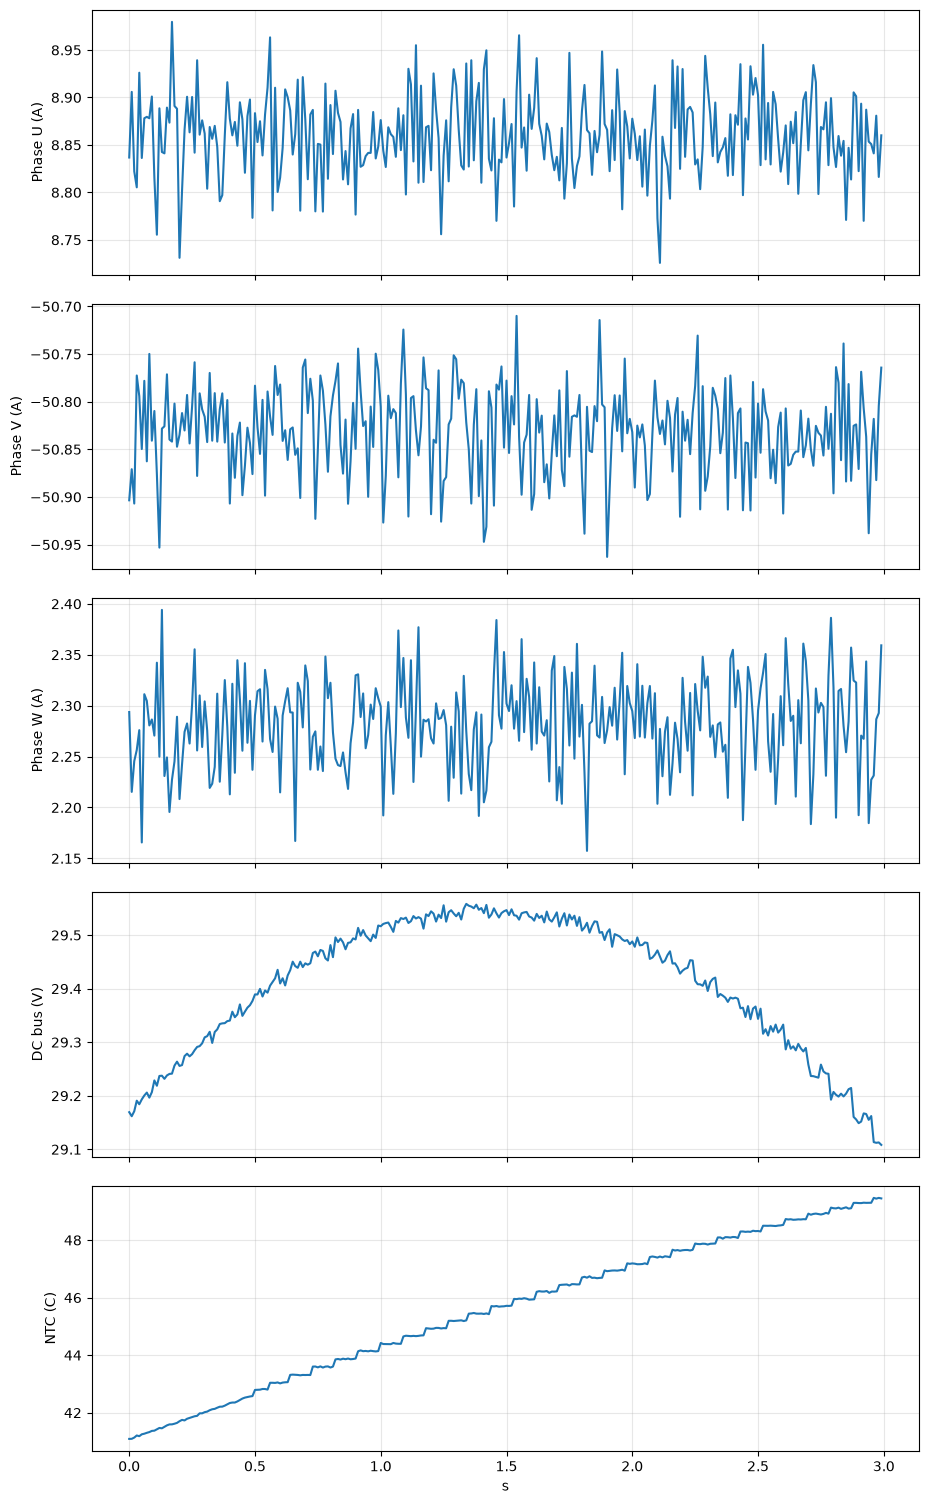

In [10]:
from coaxial.draw.figures import figure, show

units = [c for c in df.columns if c.endswith('(A)')]
shown = units + ['DC bus (V)', 'NTC (C)']
fig, panels = figure(rows=len(shown), sharex=True)
for panel, column in zip(panels, shown):
    panel.plot(df.index, df[column])
    panel.set_ylabel(column)
panels[-1].set_xlabel('s')
show(fig)

In [11]:
print(df[['Phase U', 'Phase U (A)', 'NTC', 'NTC (C)']].iloc[:3])

             Phase U  Phase U (A)           NTC    NTC (C)
elapsed                                                   
0.00     1395.961538     8.836739  42019.846154  41.089675
0.01     1406.884615     8.905885  42021.384615  41.092656
0.02     1393.653846     8.822131  42043.615385  41.135748


## 6 Currents over the switches, live

Tare with the stage off, then 4 A turning at 3.5 Hz electrical on the model: 50 records/s is 14 points a turn. `frames()` yields the last `window` s.

In [12]:
import math

daq.configure('phaseU', 'phaseV', 'phaseW', digital=True, sample_rate=50)
print(daq.channel_names())
print(device.calibration.tare('phaseU', 'phaseV', 'phaseW'))
drive = device.drive
drive.configure(source='model')
device.gates.on(bypass_sto=True, ignore_interlock=True)
drive.write(id_ref=4.0, iq_ref=0.0, theta=0.0, omega_target=2 * math.pi * 3.5)
print('holding:', drive.hold())

['Phase U', 'Phase V', 'Phase W']
{'Phase U': 1438, 'Phase V': -8078, 'Phase W': 358}
holding: True


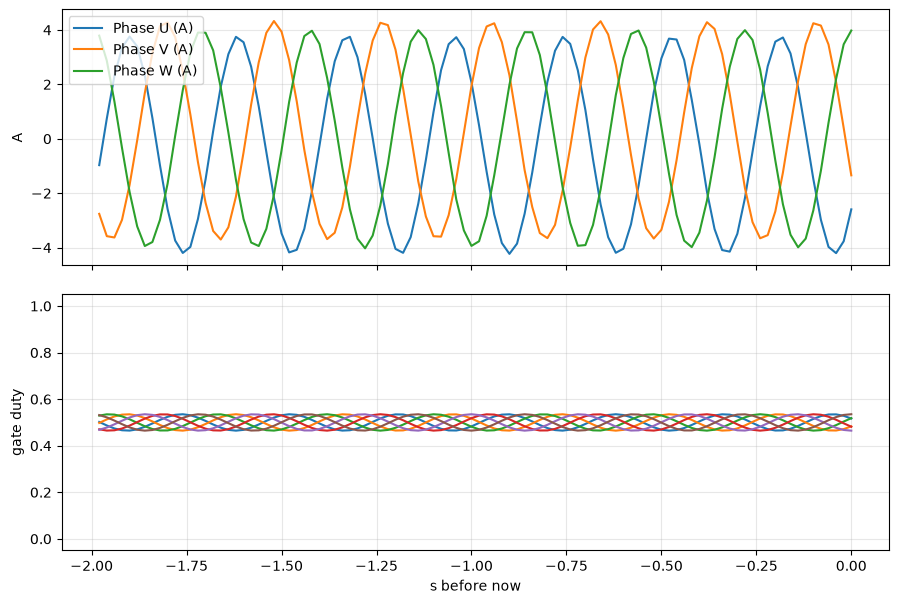

39 frames drawn; {'host': 2, 'peak': 8, 'dropped': 0, 'backlog': 0, 'reads': 135, 'records': 303, 'rate': 49.78878487481048, 'lost': 0, 'cursor': 0}
295 records held, 5.88 s back


In [13]:
from IPython.display import clear_output

daq.start()
frames = 0
for window in daq.frames(window=2.0, buffer=6.0, seconds=6.0, scaled=True):
    frames += 1
    clear_output(wait=True)
    fig, (top, bottom) = figure(rows=2, sharex=True)
    for column in (c for c in window.columns if c.endswith('(A)')):
        top.plot(window.index, window[column], label=column)
    top.set_ylabel('A')
    top.legend(loc='upper left')
    for column in (c for c in window.columns if c.startswith('TIM1_CH')):
        bottom.plot(window.index, window[column])
    bottom.set_ylabel('gate duty')
    bottom.set_ylim(-0.05, 1.05)
    bottom.set_xlabel('s before now')
    show(fig)
live = daq.buffered
daq.stop()
drive.off()
device.gates.off()
drive.configure(source='adc')
whole = daq.history(scaled=True)
print(frames, 'frames drawn;', live)
print(len(whole), 'records held,', round(-whole.index.min(), 2), 's back')

In [14]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 7 Results

In [15]:
spans = [r.dt for r in records if r.dt]
counts = [r.count for r in records]
codes = [c for c in df.columns if not c.endswith(')')]
scaled = [c for c in df.columns if c.endswith(')')]
print('1. records          %d at 50/s asked, %.2f s of covered time' % (len(records), sum(spans)))
print('2. record period    %.4f s mean = %.1f /s; dt spread %.4f to %.4f s'
      % (sum(spans) / len(spans), len(spans) / sum(spans), min(spans), max(spans)))
print('3. readings summed  %d to %d per record' % (min(counts), max(counts)))
print('4. stride           %d bytes, %d analog fields; the ring holds %d records'
      % (shape['stride'], shape['fields'], shape['capacity']))
print('5. dropped          %d, host queue peak %d' % (shape['dropped'], held['peak']))
print('6. frame            %d records, %d code columns, %d scaled columns'
      % (len(df), len(codes), len(scaled)))
for name in ('Phase U', 'DC bus', 'NTC'):
    unit = [c for c in scaled if c.startswith(name)][0]
    span = df[unit].max() - df[unit].min()
    print('   %-8s codes %8.1f +/- %6.1f   %-12s %8.3f +/- %.3f  span %.3f'
          % (name, df[name].mean(), df[name].std(), unit, df[unit].mean(),
             df[unit].std(), span))
print('7. live             %d frames in 6 s = %.1f /s; %d records %.2f s deep; '
      'reader %d reads, %.1f records/s; queue peak %d, dropped %d, board backlog %s'
      % (frames, frames / 6.0, len(whole), -whole.index.min(), live['reads'],
         live['rate'], live['peak'], live['dropped'], live['backlog']))

1. records          38 at 50/s asked, 0.74 s of covered time
2. record period    0.0200 s mean = 50.0 /s; dt spread 0.0200 to 0.0200 s
3. readings summed  132 to 132 per record
4. stride           23 bytes, 2 analog fields; the ring holds 19945 records
5. dropped          0, host queue peak 0
6. frame            300 records, 16 code columns, 5 scaled columns
   Phase U  codes   1399.7 +/-    6.9   Phase U (A)     8.860 +/- 0.044  span 0.254
   DC bus   codes  24662.1 +/-  102.7   DC bus (V)     29.409 +/- 0.123  span 0.450
   NTC      codes  44226.3 +/- 1180.8   NTC (C)        45.579 +/- 2.460  span 8.379
7. live             39 frames in 6 s = 6.5 /s; 295 records 5.88 s deep; reader 135 reads, 49.8 records/s; queue peak 8, dropped 0, board backlog 0


- `dt` is measured: the gap to the next stamp in its block (CYCCNT wraps every 9.04 s).
- `dropped`: what the ring had no room for; `buffered['lost']`: what a lapped reader lost (334 records, 16 K ring, 6 s stall - FINDINGS).
- DC link span -32 418 ppm; 49.9k/2.2k = 78.15 V full scale (invariant 11).

**Bench.** `stored` False until `calibration.span` against a meter.

## References

* `host/coaxial/rig.py` - the front door: `daq`, `set_time_from_pc`, `frame`, `frames`, `history`
* `host/coaxial/acquire/record.py` - a `Record`: the sum, the count, the mean, the struct behind a sample
* `host/coaxial/simulated/acquire/` - the stand-in this ran on, paced to real time like a board
* `daq/src/daq.c` - the engine on the board: the ring, the window, the ladder
* `docs/PROTOCOL.md` - device 6, the task and the record on the wire
* `host/tests/test_daq_api.py` - the front door pinned: naming, reading, the record shape, the buffers